In [1]:
import pandas as pd

In [3]:
base = pd.read_excel('../data/raw/Online Retail.xlsx')

In [4]:
base.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [30]:
base['TotalPrice'] = base['Quantity'] * base['UnitPrice']

In [31]:
# Tirando os valores negativos (devoluções)
base = base[base['TotalPrice'] > 0]

In [32]:
# Removendo os valores nulos
base = base.dropna(subset=['CustomerID'])

In [33]:
# Converter CustomerID para inteiro
base['CustomerID'] = base['CustomerID'].astype(int)

In [34]:
# Quantidade de clientes
base['CustomerID'].nunique()

4338

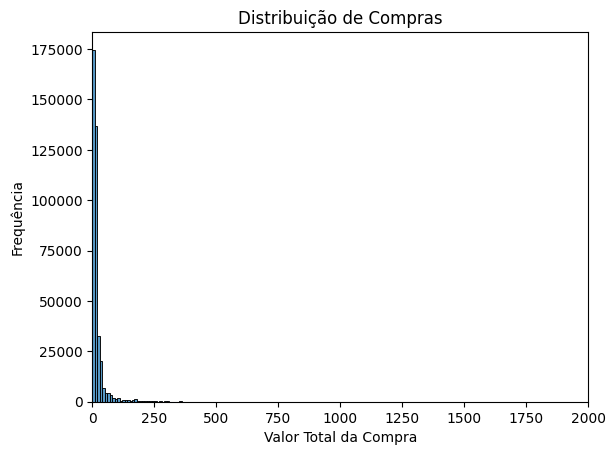

In [35]:
# Distribuição de compras
import matplotlib.pyplot as plt
import seaborn as sns

base_plot = base[base['TotalPrice'] < 500]

sns.histplot(base_plot['TotalPrice'], bins=50)
plt.xlim(0, 2000)
plt.title('Distribuição de Compras')
plt.xlabel('Valor Total da Compra')
plt.ylabel('Frequência')
plt.savefig('../imagens/distribuicao_compras.png')
plt.show()

In [36]:
base.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

In [37]:
# Salvar a base tratada
base.to_csv('../data/processed/base_tratada.csv', index=False)